Загрузите файл kaggle.json


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 365kB/s]

Данные загружены. Размер: (7043, 21)


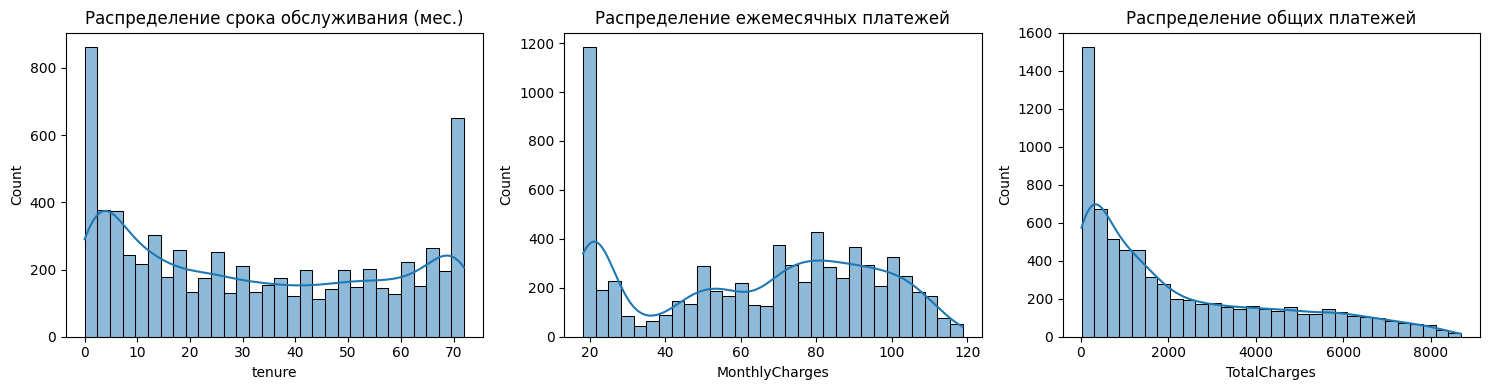

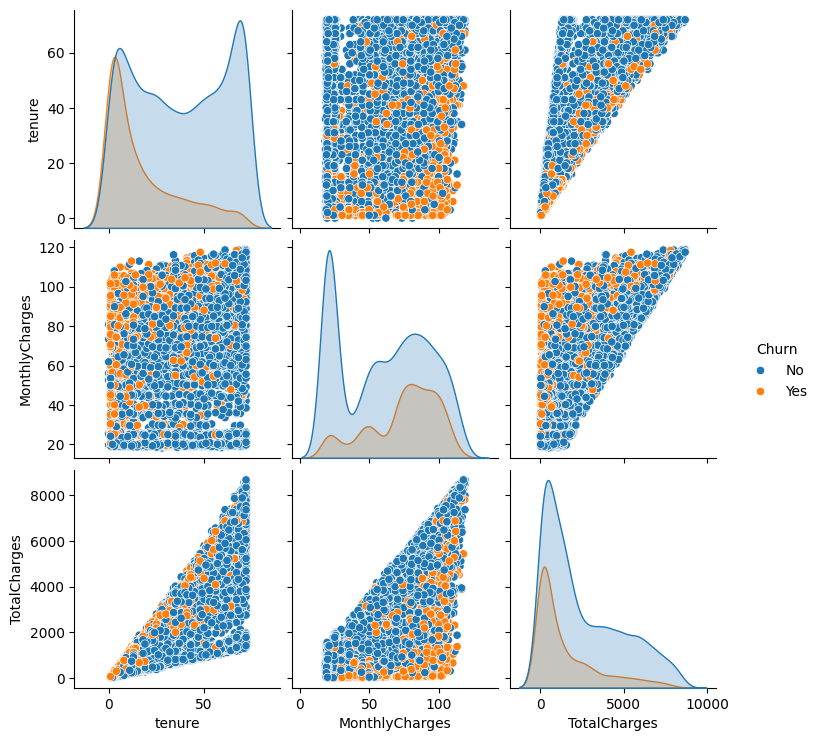

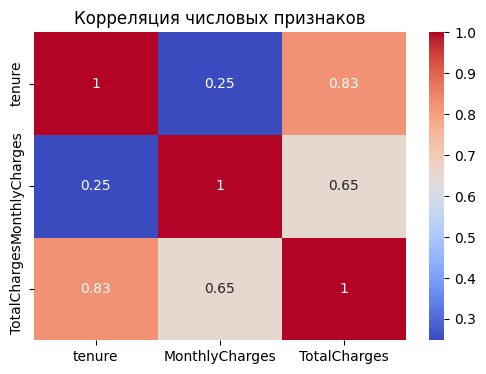


gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection:
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport:
TechSupport
No   

In [1]:
# =============================================================================
# 1. Установка и импорт библиотек
# =============================================================================
!pip install -q kaggle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import shutil
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, AffinityPropagation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import estimate_bandwidth
import matplotlib.cm as cm

# =============================================================================
# 2. Загрузка kaggle.json и датасета
# =============================================================================
# Загрузите файл kaggle.json (если не настроен API)
print("Загрузите файл kaggle.json")
uploaded = files.upload()

# Перемещаем в нужную папку
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
shutil.move('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

# Скачиваем датасет
!kaggle datasets download -d blastchar/telco-customer-churn

# Разархивируем
with zipfile.ZipFile('telco-customer-churn.zip', 'r') as zip_ref:
    zip_ref.extractall('telco-customer-churn')

# Читаем данные
df = pd.read_csv('telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Данные загружены. Размер:", df.shape)

# =============================================================================
# 3. Разведочный анализ (EDA) с предварительным преобразованием TotalCharges
# =============================================================================
# Сразу приводим TotalCharges к числовому типу (убираем пробелы)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Распределения
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['tenure'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Распределение срока обслуживания (мес.)')
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Распределение ежемесячных платежей')
sns.histplot(df['TotalCharges'].dropna(), bins=30, kde=True, ax=axes[2])  # dropna для графика
axes[2].set_title('Распределение общих платежей')
plt.tight_layout()
plt.show()

# Pairplot (пропуски во TotalCharges будут проигнорированы)
sns.pairplot(df, vars=['tenure', 'MonthlyCharges', 'TotalCharges'], hue='Churn')
plt.show()

# Корреляция (автоматически пропускает NaN)
plt.figure(figsize=(6,4))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляция числовых признаков')
plt.show()

# Категориальные признаки
cat_cols = df.select_dtypes(include='object').columns.drop('customerID', errors='ignore')
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Очистка имен столбцов и удаление ID
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# 2. TotalCharges – принудительно в числа и заполняем пропуски медианой
# 'coerce' превратит пустые строки (пробелы) в NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 3. Разделяем признаки по типу данных
binary_cols = []
multi_cols = []
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Выбираем только текстовые столбцы (object) для кодирования
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    if df[col].nunique() == 2:
        binary_cols.append(col)
    else:
        multi_cols.append(col)

# 4. Кодируем бинарные признаки (0/1) автоматически
# Это корректно обработает и Gender (Male/Female), и Churn (Yes/No)
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"Колонка '{col}' закодирована: {list(le.classes_)} -> [0, 1]")

# 5. Многоуровневые признаки -> One-Hot Encoding
# drop_first=True удаляет избыточный столбец для предотвращения мультиколлинеарности
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# 6. Финальная проверка на пропуски (на всякий случай)
nan_count = df.isnull().sum().sum()
if nan_count > 0:
    print(f"\nВнимание: обнаружено {nan_count} пропусков. Заполняем нулями...")
    df.fillna(0, inplace=True)
else:
    print("\nДанные чисты, пропусков нет.")

# 7. Подготовка данных для кластеризации
# Исключаем целевой признак 'Churn', если он есть в датасете
features = [col for col in df.columns if col != 'Churn']
X = df[features]

# 8. Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Масштабирование завершено. Форма данных: {X_scaled.shape}")
print(f"Наличие NaN в X_scaled: {np.isnan(X_scaled).any()}")


Колонка 'gender' закодирована: ['Female', 'Male'] -> [0, 1]
Колонка 'Partner' закодирована: ['No', 'Yes'] -> [0, 1]
Колонка 'Dependents' закодирована: ['No', 'Yes'] -> [0, 1]
Колонка 'PhoneService' закодирована: ['No', 'Yes'] -> [0, 1]
Колонка 'PaperlessBilling' закодирована: ['No', 'Yes'] -> [0, 1]
Колонка 'Churn' закодирована: ['No', 'Yes'] -> [0, 1]

Данные чисты, пропусков нет.
Масштабирование завершено. Форма данных: (7043, 30)
Наличие NaN в X_scaled: False


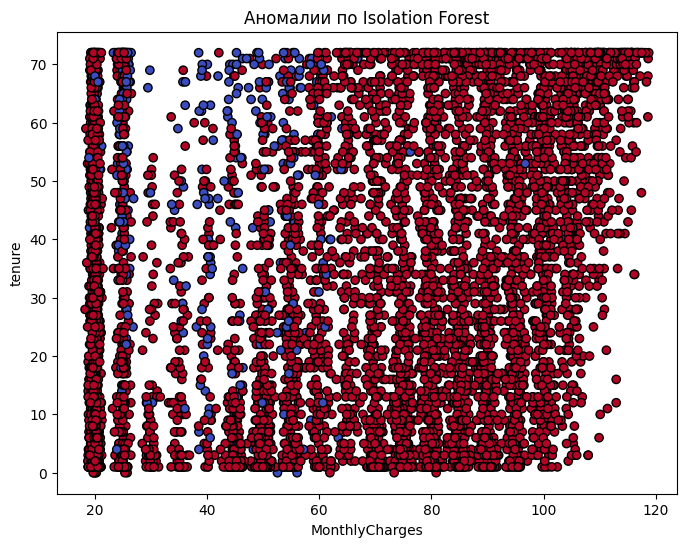

Найденные выбросы (первые 10):
     gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
71        0              0        1           1      52             1   
79        0              0        1           1      45             1   
103       0              1        1           0      66             0   
114       0              0        1           1      64             0   
129       1              1        0           0      71             0   
135       0              0        0           0      43             1   
144       1              1        1           0      71             1   
179       1              0        1           0      61             1   
216       1              0        1           1      72             0   
222       1              0        1           1       1             1   

     PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
71                  1           20.40       1090.65      0  ...   
79                  1          

In [3]:
# 5. Поиск аномалий (Isolation Forest)
# =============================================================================
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outliers = iso_forest.fit_predict(X_scaled)
df['Anomaly_IF'] = outliers

plt.figure(figsize=(8,6))
plt.scatter(df['MonthlyCharges'], df['tenure'],
            c=df['Anomaly_IF'], cmap='coolwarm', edgecolors='k')
plt.xlabel('MonthlyCharges')
plt.ylabel('tenure')
plt.title('Аномалии по Isolation Forest')
plt.show()
print("Найденные выбросы (первые 10):")
print(df[outliers == -1].head(10))


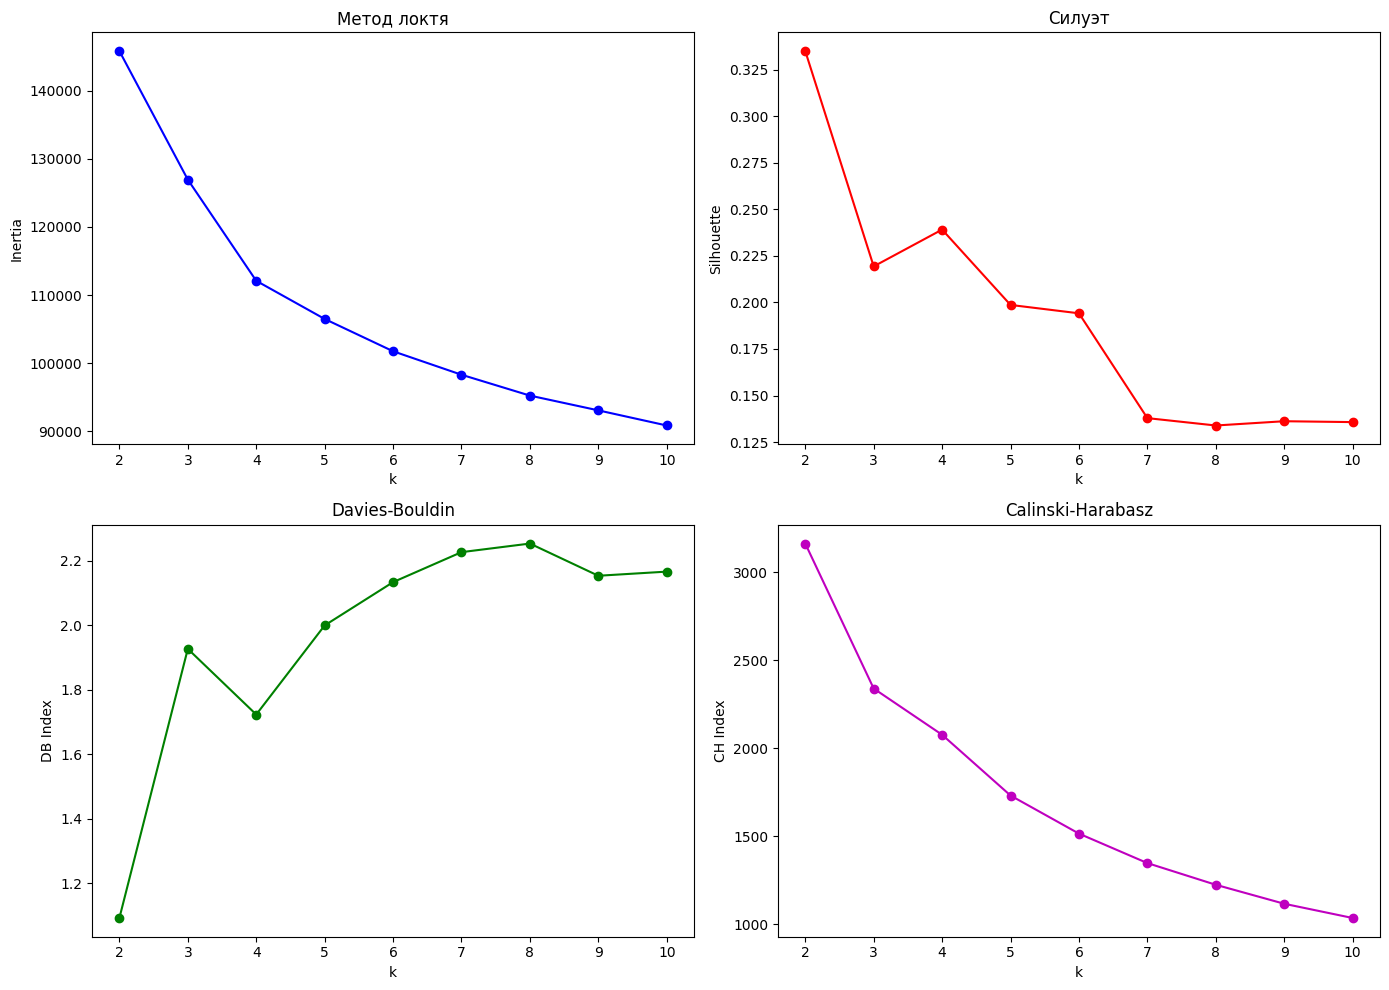

Оптимальное k для KMeans: 2


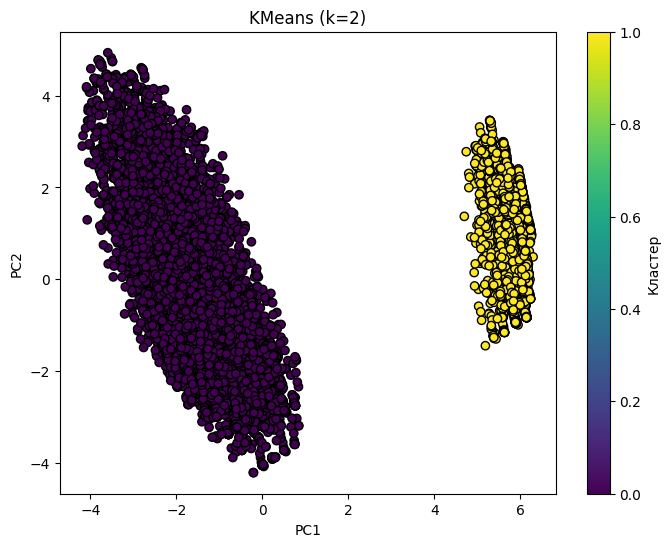

In [4]:
# 6. KMeans с подбором оптимального k
# =============================================================================
k_range = range(2, 11)
inertia, sil_kmeans, db_kmeans, ch_kmeans = [], [], [], []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_kmeans.append(silhouette_score(X_scaled, labels))
    db_kmeans.append(davies_bouldin_score(X_scaled, labels))
    ch_kmeans.append(calinski_harabasz_score(X_scaled, labels))

# Визуализация метрик
plt.figure(figsize=(14,10))
plt.subplot(2,2,1); plt.plot(k_range, inertia, 'bo-'); plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Метод локтя')
plt.subplot(2,2,2); plt.plot(k_range, sil_kmeans, 'ro-'); plt.xlabel('k'); plt.ylabel('Silhouette'); plt.title('Силуэт')
plt.subplot(2,2,3); plt.plot(k_range, db_kmeans, 'go-'); plt.xlabel('k'); plt.ylabel('DB Index'); plt.title('Davies-Bouldin')
plt.subplot(2,2,4); plt.plot(k_range, ch_kmeans, 'mo-'); plt.xlabel('k'); plt.ylabel('CH Index'); plt.title('Calinski-Harabasz')
plt.tight_layout()
plt.show()

best_k_kmeans = k_range[np.argmax(sil_kmeans)]
print(f"Оптимальное k для KMeans: {best_k_kmeans}")

kmeans_best = KMeans(n_clusters=best_k_kmeans, random_state=42, n_init=10)
clusters_kmeans = kmeans_best.fit_predict(X_scaled)
df['Cluster_KMeans'] = clusters_kmeans

# Визуализация через PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_kmeans, cmap='viridis', edgecolors='k')
plt.title(f'KMeans (k={best_k_kmeans})')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.colorbar(label='Кластер')
plt.show()


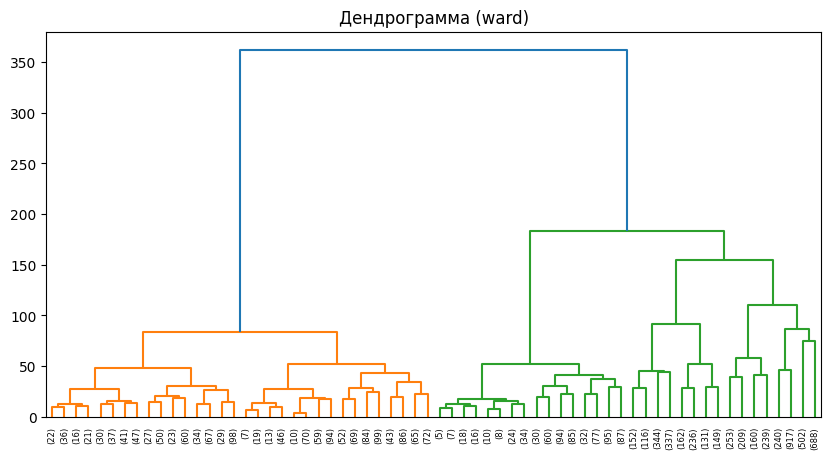

Оптимальное k для Agglomerative: 2


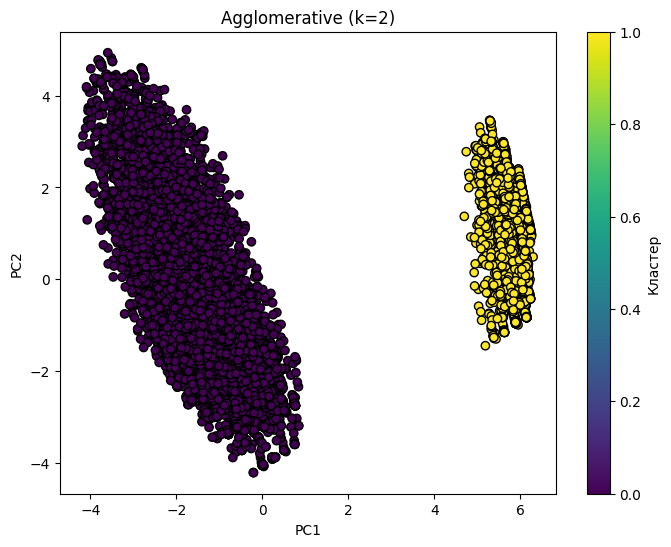

In [5]:
# 7. Агломеративная кластеризация
# =============================================================================
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Дендрограмма (ward)')
plt.show()

sil_agg, db_agg, ch_agg = [], [], []
for k in k_range:
    agg = AgglomerativeClustering(n_clusters=k)
    labels = agg.fit_predict(X_scaled)
    sil_agg.append(silhouette_score(X_scaled, labels))
    db_agg.append(davies_bouldin_score(X_scaled, labels))
    ch_agg.append(calinski_harabasz_score(X_scaled, labels))

best_k_agg = k_range[np.argmax(sil_agg)]
print(f"Оптимальное k для Agglomerative: {best_k_agg}")

agg_best = AgglomerativeClustering(n_clusters=best_k_agg)
clusters_agg = agg_best.fit_predict(X_scaled)
df['Cluster_Agg'] = clusters_agg

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_agg, cmap='viridis', edgecolors='k')
plt.title(f'Agglomerative (k={best_k_agg})')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.colorbar(label='Кластер')
plt.show()


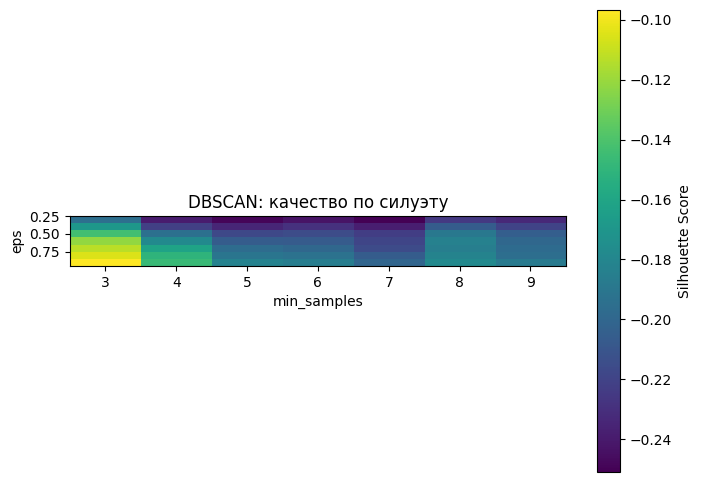

Лучшие параметры DBSCAN: eps=0.9, min_samples=3
Лучший силуэт: -0.0967


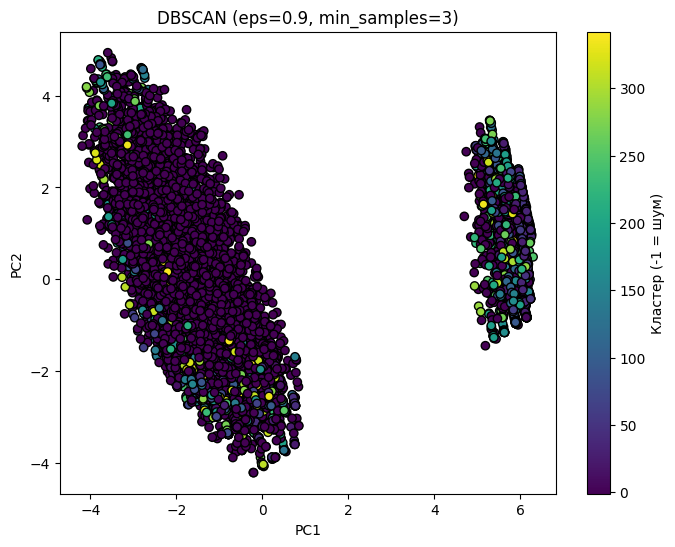

Число кластеров (без шума): 343
Метрики DBSCAN: Silhouette=-0.0967, DB=0.9862, CH=13.0049


In [7]:
 8.# DBSCAN
# =============================================================================
eps_values = np.arange(0.3, 1.0, 0.1)
min_samples_values = range(3, 10)

best_score_db = -1
best_params_db = None
best_labels_db = None
results_db = np.zeros((len(eps_values), len(min_samples_values)))

for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters < 2:
            results_db[i, j] = -1
            continue
        sil = silhouette_score(X_scaled, labels)
        results_db[i, j] = sil
        if sil > best_score_db:
            best_score_db = sil
            best_params_db = (eps, min_samples)
            best_labels_db = labels

# Визуализация heatmap
plt.figure(figsize=(8,6))
plt.imshow(results_db, interpolation='nearest', cmap='viridis',
           extent=[min_samples_values[0]-0.5, min_samples_values[-1]+0.5, eps_values[-1]+0.05, eps_values[0]-0.05])
plt.colorbar(label='Silhouette Score')
plt.xlabel('min_samples'); plt.ylabel('eps')
plt.title('DBSCAN: качество по силуэту')
plt.show()

if best_params_db:
    print(f"Лучшие параметры DBSCAN: eps={best_params_db[0]:.1f}, min_samples={best_params_db[1]}")
    print(f"Лучший силуэт: {best_score_db:.4f}")
    db_best = DBSCAN(eps=best_params_db[0], min_samples=best_params_db[1])
    clusters_dbscan = db_best.fit_predict(X_scaled)
    df['Cluster_DBSCAN'] = clusters_dbscan

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_dbscan, cmap='viridis', edgecolors='k')
    plt.title(f"DBSCAN (eps={best_params_db[0]:.1f}, min_samples={best_params_db[1]})")
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.colorbar(label='Кластер (-1 = шум)')
    plt.show()

    n_clusters_db = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
    print(f"Число кластеров (без шума): {n_clusters_db}")
    if n_clusters_db >= 2:
        sil_db = silhouette_score(X_scaled, clusters_dbscan)
        db_db = davies_bouldin_score(X_scaled, clusters_dbscan)
        ch_db = calinski_harabasz_score(X_scaled, clusters_dbscan)
        print(f"Метрики DBSCAN: Silhouette={sil_db:.4f}, DB={db_db:.4f}, CH={ch_db:.4f}")
else:
    print("DBSCAN не нашёл подходящих параметров с двумя и более кластерами.")
    clusters_dbscan = None  # для последующего сравнения

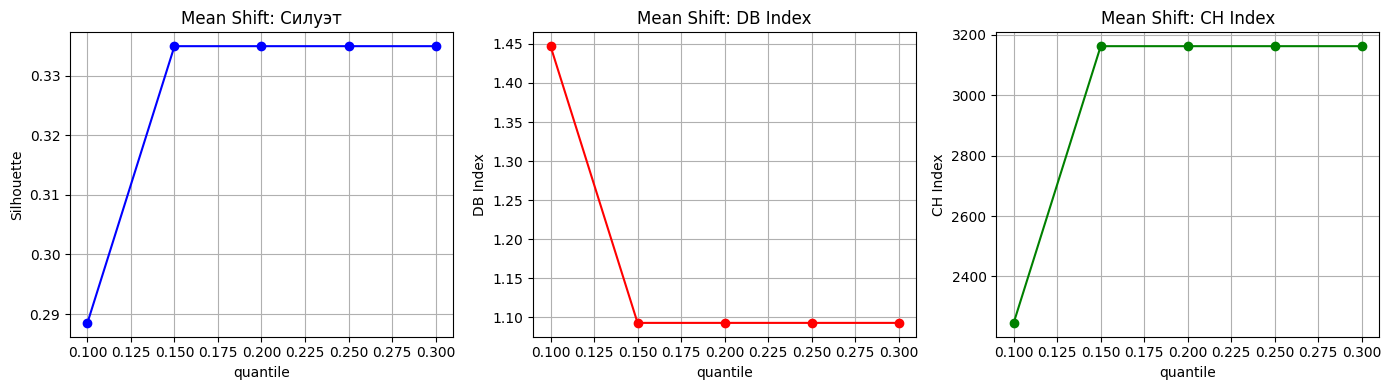

Лучший quantile: 0.15, bandwidth: 5.508
Лучший силуэт: 0.3349
Число кластеров Mean Shift: 2


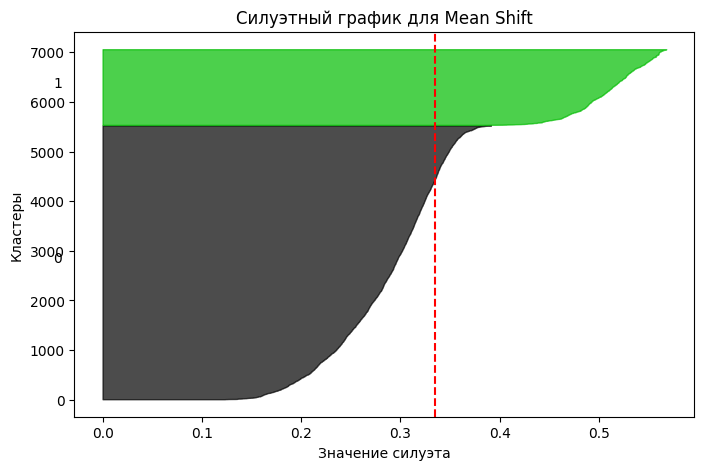

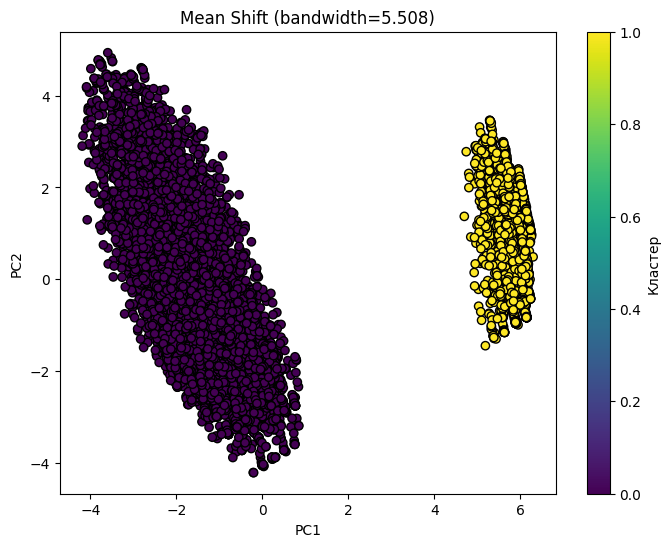

Метрики Mean Shift: Silhouette=0.3349, DB=1.0930, CH=3162.3340


In [8]:
# 9. Mean Shift
# =============================================================================
quantiles = np.arange(0.1, 0.55, 0.05)
sil_ms, db_ms, ch_ms = [], [], []
best_bandwidth = None
best_labels_ms = None
best_score_ms = -1
best_q = None

for q in quantiles:
    bandwidth = estimate_bandwidth(X_scaled, quantile=q, n_samples=100)
    if bandwidth is None or bandwidth <= 0:
        continue
    ms = MeanShift(bandwidth=bandwidth)
    labels = ms.fit_predict(X_scaled)
    n_clusters = len(set(labels))
    if n_clusters < 2:
        continue
    sil = silhouette_score(X_scaled, labels)
    sil_ms.append(sil)
    db_ms.append(davies_bouldin_score(X_scaled, labels))
    ch_ms.append(calinski_harabasz_score(X_scaled, labels))
    if sil > best_score_ms:
        best_score_ms = sil
        best_bandwidth = bandwidth
        best_labels_ms = labels
        best_q = q

# Визуализация
if sil_ms:
    plt.figure(figsize=(14,4))
    plt.subplot(1,3,1); plt.plot(quantiles[:len(sil_ms)], sil_ms, 'bo-'); plt.xlabel('quantile'); plt.ylabel('Silhouette'); plt.title('Mean Shift: Силуэт'); plt.grid(True)
    plt.subplot(1,3,2); plt.plot(quantiles[:len(db_ms)], db_ms, 'ro-'); plt.xlabel('quantile'); plt.ylabel('DB Index'); plt.title('Mean Shift: DB Index'); plt.grid(True)
    plt.subplot(1,3,3); plt.plot(quantiles[:len(ch_ms)], ch_ms, 'go-'); plt.xlabel('quantile'); plt.ylabel('CH Index'); plt.title('Mean Shift: CH Index'); plt.grid(True)
    plt.tight_layout()
    plt.show()

if best_labels_ms is not None:
    print(f"Лучший quantile: {best_q:.2f}, bandwidth: {best_bandwidth:.3f}")
    print(f"Лучший силуэт: {best_score_ms:.4f}")

    ms_best = MeanShift(bandwidth=best_bandwidth)
    clusters_ms = ms_best.fit_predict(X_scaled)
    df['Cluster_MeanShift'] = clusters_ms
    n_clusters_ms = len(set(clusters_ms))
    print(f"Число кластеров Mean Shift: {n_clusters_ms}")

    # Силуэтный график
    sample_silhouette_values = silhouette_samples(X_scaled, clusters_ms)
    fig, ax = plt.subplots(figsize=(8,5))
    y_lower = 10
    for i in range(n_clusters_ms):
        ith_cluster_silhouette_values = sample_silhouette_values[clusters_ms == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(float(i) / n_clusters_ms)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    ax.axvline(x=best_score_ms, color="red", linestyle="--")
    ax.set_title("Силуэтный график для Mean Shift")
    ax.set_xlabel("Значение силуэта"); ax.set_ylabel("Кластеры")
    plt.show()

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_ms, cmap='viridis', edgecolors='k')
    plt.title(f"Mean Shift (bandwidth={best_bandwidth:.3f})")
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.colorbar(label='Кластер')
    plt.show()

    sil_ms_final = silhouette_score(X_scaled, clusters_ms)
    db_ms_final = davies_bouldin_score(X_scaled, clusters_ms)
    ch_ms_final = calinski_harabasz_score(X_scaled, clusters_ms)
    print(f"Метрики Mean Shift: Silhouette={sil_ms_final:.4f}, DB={db_ms_final:.4f}, CH={ch_ms_final:.4f}")
else:
    print("Mean Shift не нашёл подходящих параметров.")
    clusters_ms = None

Affinity Propagation нашёл 350 кластеров


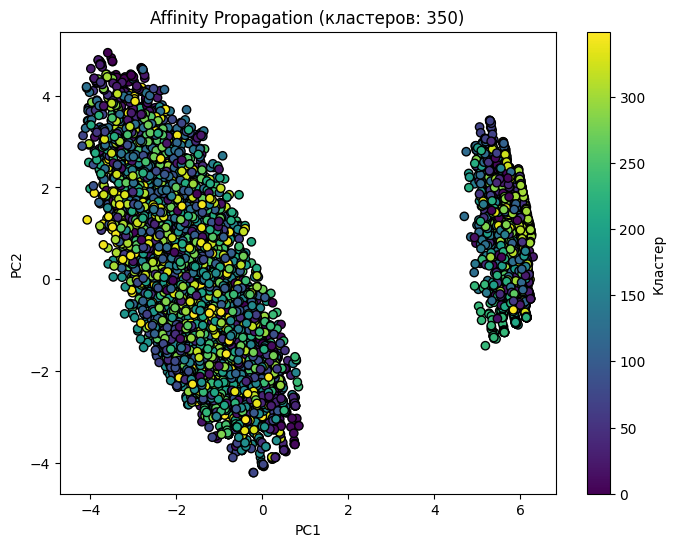

Метрики Affinity Propagation: Silhouette=0.1308, DB=1.8139, CH=83.3235


In [10]:
# 10. Affinity Propagation
# =============================================================================
ap = AffinityPropagation(random_state=42)
clusters_ap = ap.fit_predict(X_scaled)
df['Cluster_AffinityProp'] = clusters_ap

n_clusters_ap = len(set(clusters_ap))
print(f"Affinity Propagation нашёл {n_clusters_ap} кластеров")

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_ap, cmap='viridis', edgecolors='k')
plt.title(f"Affinity Propagation (кластеров: {n_clusters_ap})")
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.colorbar(label='Кластер')
plt.show()

if n_clusters_ap >= 2:
    sil_ap = silhouette_score(X_scaled, clusters_ap)
    db_ap = davies_bouldin_score(X_scaled, clusters_ap)
    ch_ap = calinski_harabasz_score(X_scaled, clusters_ap)
    print(f"Метрики Affinity Propagation: Silhouette={sil_ap:.4f}, DB={db_ap:.4f}, CH={ch_ap:.4f}")
else:
    print("Недостаточно кластеров для расчёта метрик.")

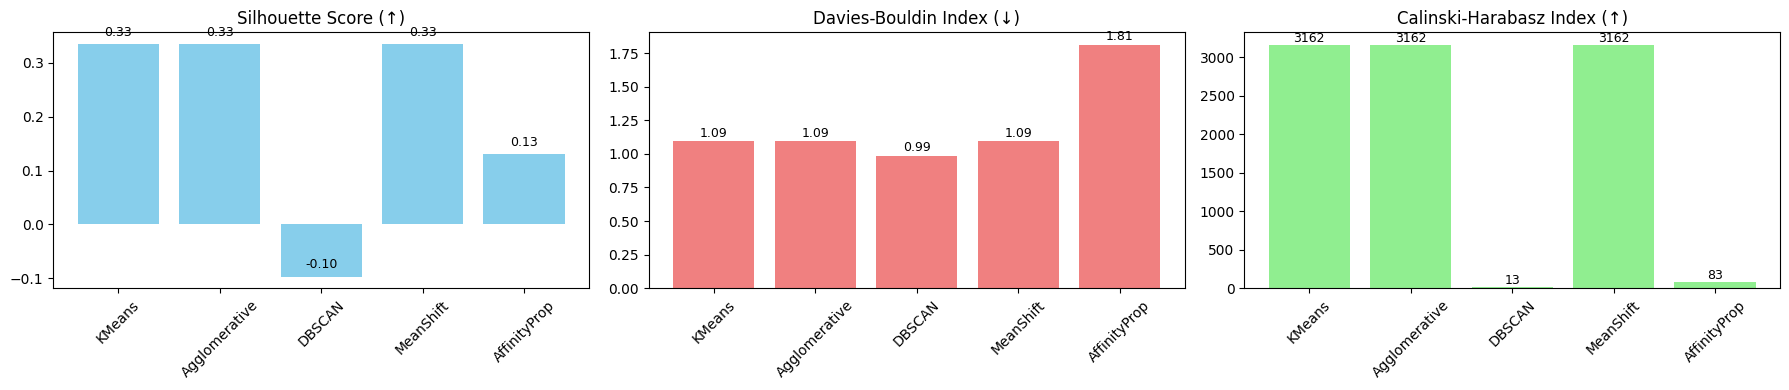

Сравнительная таблица методов кластеризации:

        Метод  Silhouette (↑)  Davies-Bouldin (↓)  Calinski-Harabasz (↑)
       KMeans        0.334942            1.092954            3162.333982
Agglomerative        0.334942            1.092954            3162.333982
    MeanShift        0.334942            1.092954            3162.333982
 AffinityProp        0.130791            1.813880              83.323469
       DBSCAN       -0.096697            0.986157              13.004945


In [11]:
# 11. Сравнение методов
# =============================================================================
method_names = ['KMeans', 'Agglomerative', 'DBSCAN', 'MeanShift', 'AffinityProp']
all_labels = [
    clusters_kmeans,
    clusters_agg,
    clusters_dbscan if 'clusters_dbscan' in dir() else None,
    clusters_ms if 'clusters_ms' in dir() else None,
    clusters_ap
]

sil_scores, db_scores, ch_scores = [], [], []
for labels in all_labels:
    if labels is not None and len(set(labels)) >= 2:
        sil_scores.append(silhouette_score(X_scaled, labels))
        db_scores.append(davies_bouldin_score(X_scaled, labels))
        ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    else:
        sil_scores.append(np.nan)
        db_scores.append(np.nan)
        ch_scores.append(np.nan)

# Графики
plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
bars1 = plt.bar(method_names, sil_scores, color='skyblue')
plt.title('Silhouette Score (↑)'); plt.xticks(rotation=45)
for bar, val in zip(bars1, sil_scores):
    if not np.isnan(val):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.subplot(1,3,2)
bars2 = plt.bar(method_names, db_scores, color='lightcoral')
plt.title('Davies-Bouldin Index (↓)'); plt.xticks(rotation=45)
for bar, val in zip(bars2, db_scores):
    if not np.isnan(val):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.subplot(1,3,3)
bars3 = plt.bar(method_names, ch_scores, color='lightgreen')
plt.title('Calinski-Harabasz Index (↑)'); plt.xticks(rotation=45)
for bar, val in zip(bars3, ch_scores):
    if not np.isnan(val):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Таблица результатов
results_df = pd.DataFrame({
    'Метод': method_names,
    'Silhouette (↑)': sil_scores,
    'Davies-Bouldin (↓)': db_scores,
    'Calinski-Harabasz (↑)': ch_scores
}).sort_values('Silhouette (↑)', ascending=False).reset_index(drop=True)

print("Сравнительная таблица методов кластеризации:\n")
print(results_df.to_string(index=False))



Лучший метод: KMeans

Профили кластеров (средние значения ключевых признаков):
                   tenure  MonthlyCharges  TotalCharges     Churn
Cluster_KMeans                                                   
0               32.875657       76.844254   2728.298201  0.318289
1               30.547182       21.079194    668.099443  0.074050


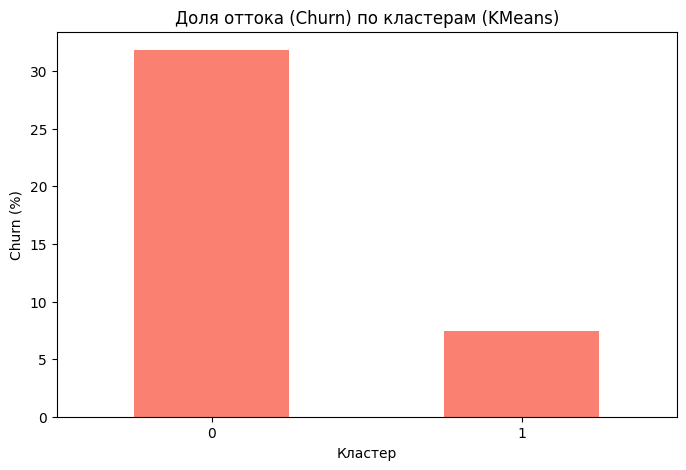

In [12]:
# 12. Интерпретация лучшего метода
# =============================================================================
best_method = results_df.iloc[0]['Метод']
print(f"\nЛучший метод: {best_method}")

# Получим метки кластеров для лучшего метода
if best_method == 'KMeans':
    best_clusters = df['Cluster_KMeans']
elif best_method == 'Agglomerative':
    best_clusters = df['Cluster_Agg']
elif best_method == 'DBSCAN' and 'Cluster_DBSCAN' in df.columns:
    best_clusters = df['Cluster_DBSCAN']
elif best_method == 'MeanShift' and 'Cluster_MeanShift' in df.columns:
    best_clusters = df['Cluster_MeanShift']
elif best_method == 'AffinityProp':
    best_clusters = df['Cluster_AffinityProp']
else:
    best_clusters = None

if best_clusters is not None:
    # Добавим Churn для анализа (уже есть, просто убедимся, что числовой)
    df['Churn'] = df['Churn'].astype(int)
    cluster_profile = df.groupby(best_clusters).mean(numeric_only=True)
    print("\nПрофили кластеров (средние значения ключевых признаков):")
    print(cluster_profile[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

    # Доля оттока по кластерам
    churn_by_cluster = df.groupby(best_clusters)['Churn'].mean() * 100
    plt.figure(figsize=(8,5))
    churn_by_cluster.plot(kind='bar', color='salmon')
    plt.title(f'Доля оттока (Churn) по кластерам ({best_method})')
    plt.xlabel('Кластер')
    plt.ylabel('Churn (%)')
    plt.xticks(rotation=0)
    plt.show()


In [13]:
# 13. Итоговые выводы
# =============================================================================
print("\n" + "="*70)
print("ВЫВОДЫ ПО РЕЗУЛЬТАТАМ КЛАСТЕРИЗАЦИИ ТЕЛЕКОМ-КЛИЕНТОВ")
print("="*70)
print(f"\n1. Лучший метод по силуэту: **{best_method}** (Silhouette = {results_df.iloc[0]['Silhouette (↑)']:.4f}).")
print(f"   Davies-Bouldin Index = {results_df.iloc[0]['Davies-Bouldin (↓)']:.4f},")
print(f"   Calinski-Harabasz Index = {results_df.iloc[0]['Calinski-Harabasz (↑)']:.0f}.")
print("\n2. Рекомендация: Использовать полученные кластеры для персонализации маркетинга и удержания клиентов.")
print("   Анализ профилей кластеров позволяет выделить группы с высоким/низким оттоком и разработать таргетированные предложения.")


ВЫВОДЫ ПО РЕЗУЛЬТАТАМ КЛАСТЕРИЗАЦИИ ТЕЛЕКОМ-КЛИЕНТОВ

1. Лучший метод по силуэту: **KMeans** (Silhouette = 0.3349).
   Davies-Bouldin Index = 1.0930,
   Calinski-Harabasz Index = 3162.

2. Рекомендация: Использовать полученные кластеры для персонализации маркетинга и удержания клиентов.
   Анализ профилей кластеров позволяет выделить группы с высоким/низким оттоком и разработать таргетированные предложения.


In [14]:
# Добавляем метки кластеров в исходный датафрейм (не в PCA!)
df['cluster'] = labels

# Считаем среднее для каждого признака в разрезе кластеров
cluster_profile = df.groupby('cluster').mean()

# Выводим разницу
print(cluster_profile.T)

cluster                                        0            1          2    \
gender                                    0.800000     0.315789   1.000000   
SeniorCitizen                             0.000000     0.000000   0.000000   
Partner                                   0.266667     0.947368   0.000000   
Dependents                                0.200000     0.947368   0.000000   
tenure                                   32.800000    66.631579   1.000000   
PhoneService                              1.000000     1.000000   1.000000   
PaperlessBilling                          0.066667     0.052632   0.000000   
MonthlyCharges                           61.383333   110.797368  20.133333   
TotalCharges                           2014.406667  7367.515789  20.133333   
Churn                                     0.000000     0.000000   1.000000   
MultipleLines_No phone service            0.000000     0.000000   0.000000   
MultipleLines_Yes                         0.200000     0.894737 

In [15]:
# Заново получаем метки (подставьте лучший bandwidth, например 5.333)
from sklearn.cluster import MeanShift
ms = MeanShift(bandwidth=5.333)
labels_meanshift = ms.fit_predict(X_pca) # X_pca - данные после сжатия

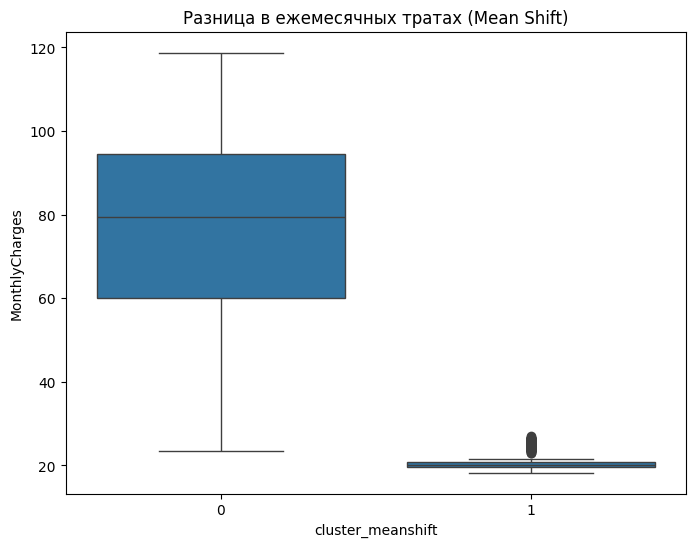

In [17]:
# Анализ разделения методои Ms на кластеры (по ежемесячным расходам)
#1. Сначала получаем метки из модели (меняем 'ms' на имя  переменной модели)
# Если вы обучали модель как ms = MeanShift(...).fit(X_pca)
labels_meanshift = ms.labels_

# 2. Теперь добавляем их в таблицу
df['cluster_meanshift'] = labels_meanshift

# 3. И только теперь рисуем график
plt.figure(figsize=(8, 6))
sns.boxplot(x='cluster_meanshift', y='MonthlyCharges', data=df)
plt.title('Разница в ежемесячных тратах (Mean Shift)')
plt.show()

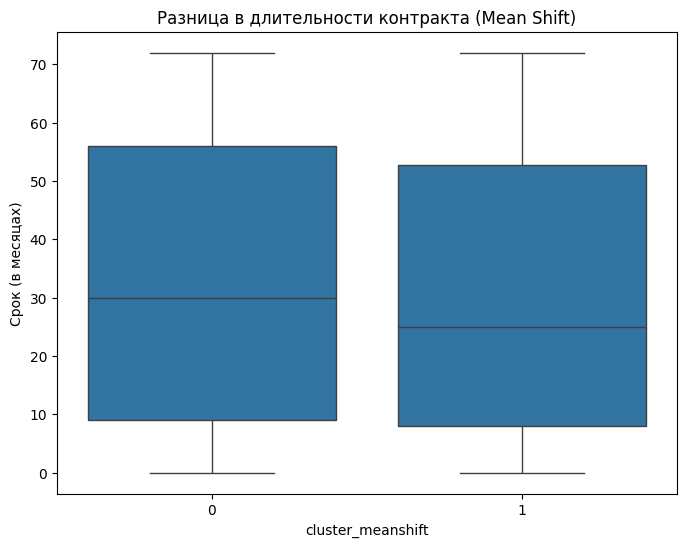

In [18]:
#Анализ по длительности контракта (Tenure)
import seaborn as sns
import matplotlib.pyplot as plt

# Если вы не уверены в названии колонки, раскомментируйте строку ниже, чтобы увидеть список:
# print(df.columns)

plt.figure(figsize=(8, 6))
# Замените 'tenure' на точное название вашей колонки (например, 'TotalMonths' или 'age')
sns.boxplot(x='cluster_meanshift', y='tenure', data=df)

plt.title('Разница в длительности контракта (Mean Shift)')
plt.ylabel('Срок (в месяцах)')
plt.show()

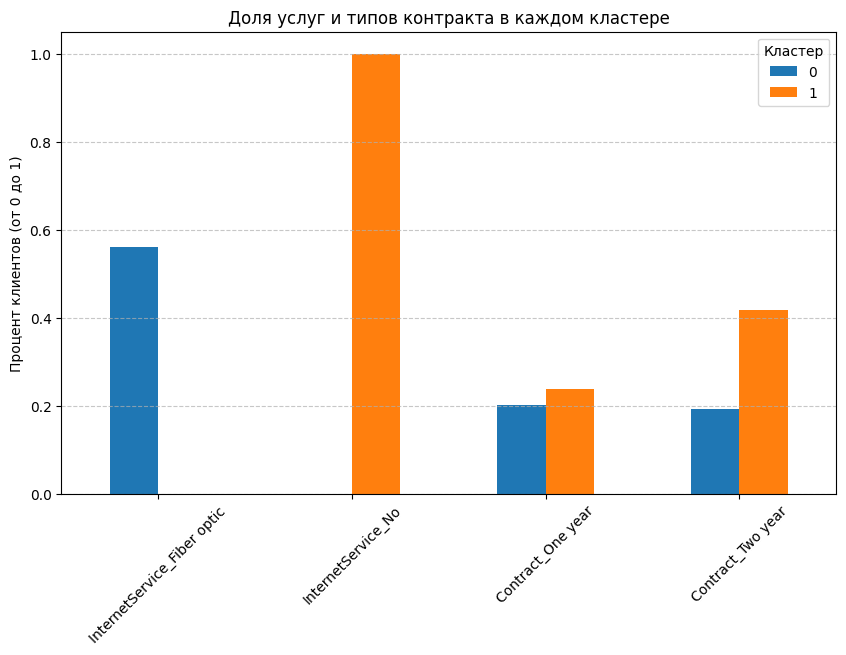

                   InternetService_Fiber optic  InternetService_No  \
cluster_meanshift                                                    
0                                     0.561175                 0.0   
1                                     0.000000                 1.0   

                   Contract_One year  Contract_Two year  
cluster_meanshift                                        
0                           0.201015           0.191590  
1                           0.238532           0.418087  


In [19]:
#Анализ групп по типу контракта (месячный, годовой)
import pandas as pd
import matplotlib.pyplot as plt

# Список колонок, которые нас интересуют (взяты прямо из вашего списка)
features_to_check = [
    'InternetService_Fiber optic',
    'InternetService_No',
    'Contract_One year',
    'Contract_Two year'
]

# Группируем по нашему кластеру и считаем среднее (долю людей с этой услугой)
analysis = df.groupby('cluster_meanshift')[features_to_check].mean()

# Рисуем красивый график
analysis.T.plot(kind='bar', figsize=(10, 6))
plt.title('Доля услуг и типов контракта в каждом кластере')
plt.ylabel('Процент клиентов (от 0 до 1)')
plt.xticks(rotation=45)
plt.legend(title='Кластер')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Выведем еще и цифрами для точности
print(analysis)

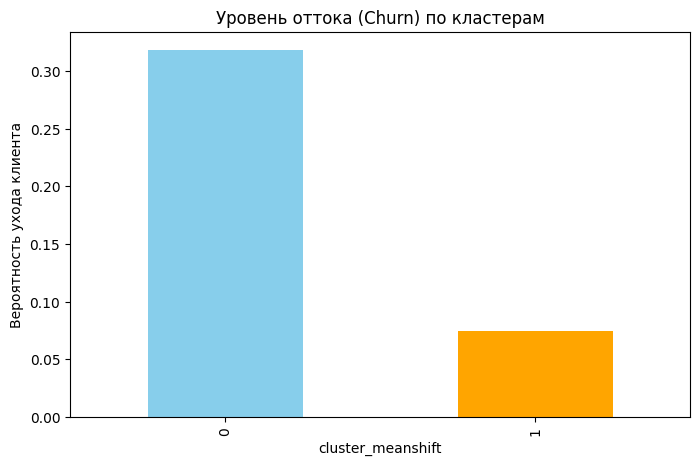

Процент ушедших клиентов в Кластере 0 (Синие): 31.8%
Процент ушедших клиентов в Кластере 1 (Оранжевые): 7.4%


In [20]:
# Посмотрим средний уровень оттока, как самого важного вопроса для бизнеса (если Churn - это 0 и 1)
churn_analysis = df.groupby('cluster_meanshift')['Churn'].mean()

plt.figure(figsize=(8, 5))
churn_analysis.plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Уровень оттока (Churn) по кластерам')
plt.ylabel('Вероятность ухода клиента')
plt.show()

print(f"Процент ушедших клиентов в Кластере 0 (Синие): {churn_analysis[0]*100:.1f}%")
print(f"Процент ушедших клиентов в Кластере 1 (Оранжевые): {churn_analysis[1]*100:.1f}%")


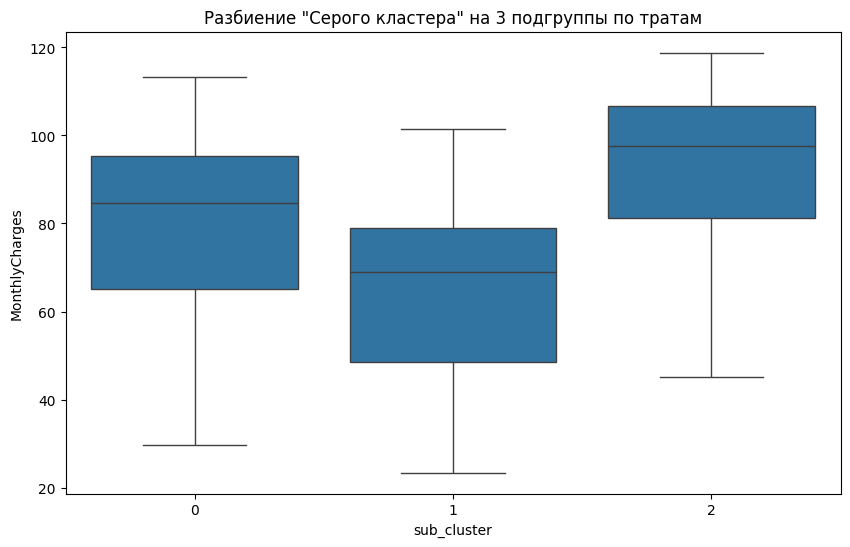

In [21]:
# Анализ "серого кластера " по MC на предмет его неоднородности (какие можем выделить подсегменты)
from sklearn.cluster import KMeans

# 1. Выделяем данные только для нулевого кластера
df_sub = df[df['cluster_meanshift'] == 0].copy()

# 2. Берем те же данные, на которых учился PCA (или сам PCA), но только для этих строк
# Предположим, X_pca — это массив после PCA
X_sub = X_pca[df['cluster_meanshift'] == 0]

# 3. Разбиваем на 3 подгруппы (Эконом, Стандарт, Премиум)
kmeans_sub = KMeans(n_clusters=3, random_state=42, n_init=10)
df_sub['sub_cluster'] = kmeans_sub.fit_predict(X_sub)

# 4. Посмотрим, чем они отличаются по деньгам
plt.figure(figsize=(10, 6))
sns.boxplot(x='sub_cluster', y='MonthlyCharges', data=df_sub)
plt.title('Разбиение "Серого кластера" на 3 подгруппы по тратам')
plt.show()


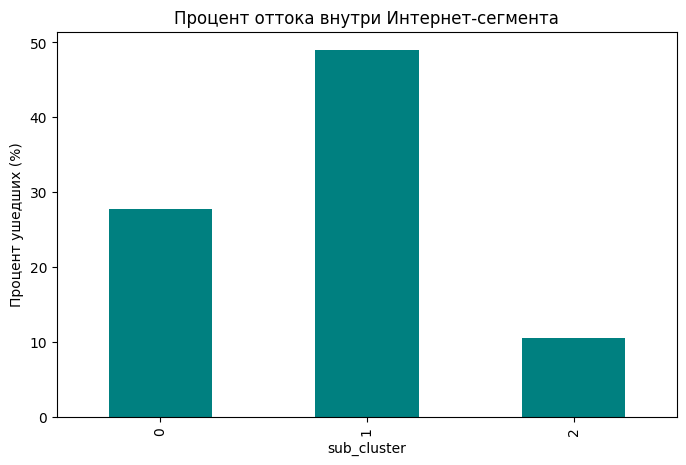

sub_cluster
0    27.769347
1    48.985240
2    10.568513
Name: Churn, dtype: float64


In [22]:
# Считаем отток для каждого из трех новых сегментов
sub_churn = df_sub.groupby('sub_cluster')['Churn'].mean() * 100

plt.figure(figsize=(8, 5))
sub_churn.plot(kind='bar', color='teal')
plt.title('Процент оттока внутри Интернет-сегмента')
plt.ylabel('Процент ушедших (%)')
plt.show()

print(sub_churn)


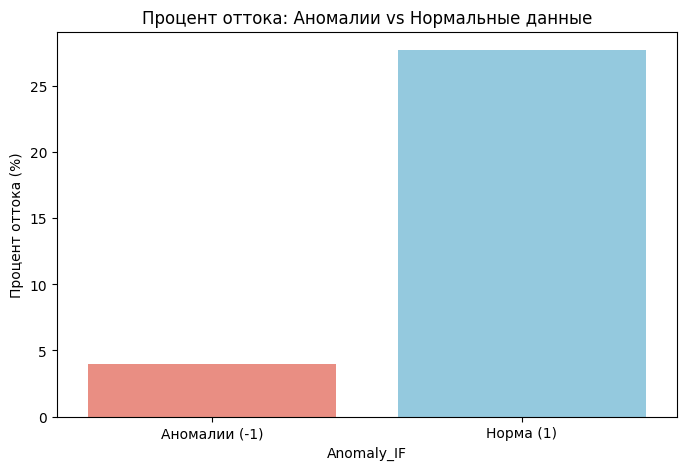

Отток среди аномалий: 4.0%
Отток в нормальных данных: 27.7%


In [23]:
#Анализ аномалий дополнительный (как сильно аномалии влияют на процент оттока)
import seaborn as sns
import matplotlib.pyplot as plt

# Считаем средний отток для аномалий и нормы
# Напомним: -1 — это аномалия (синие), 1 — это норма (красные)
anomaly_churn = df.groupby('Anomaly_IF')['Churn'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=anomaly_churn.index, y=anomaly_churn.values, palette=['salmon', 'skyblue'])
plt.title('Процент оттока: Аномалии vs Нормальные данные')
plt.xticks(ticks=[0, 1], labels=['Аномалии (-1)', 'Норма (1)'])
plt.ylabel('Процент оттока (%)')
plt.show()

print(f"Отток среди аномалий: {anomaly_churn[-1]:.1f}%")
print(f"Отток в нормальных данных: {anomaly_churn[1]:.1f}%")
